<a href="https://colab.research.google.com/github/eshat69/Customer-Churn-Analysis/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from pandas.api.types import is_numeric_dtype

In [24]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("/content/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [26]:
x = df.drop(["RowNumber",	"CustomerId",	"Surname", "Exited"], axis=1)
y = df[["Exited"]]

In [27]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [28]:
std = StandardScaler()
ord = OrdinalEncoder()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [30]:
for col in x.columns:
  if not is_numeric_dtype(x[col]):
    x[col]= ord.fit_transform(x[[col]]).ravel()
  else:
    x[col]= std.fit_transform(x[[col]]).ravel()

In [31]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [59]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=.15, random_state= 42)


# : Input → Hidden Dense + Dropout layers → Flatten → Dense → Sigmoid Output → a binary classification neural network with regularization.

In [60]:
model = Sequential()
model.add(Dense(input_dim= 10, kernel_initializer="he_normal", activation="relu", units=15))
model.add(Dropout(.2))

model.add(Dense( kernel_initializer="he_normal", activation="relu", units=20))
model.add(Dropout(.2))

model.add(Dense(kernel_initializer="he_normal", activation="relu", units=18))
model.add(Dropout(.2))

model.add(Flatten())

model.add(Dense(kernel_initializer="he_normal", activation="relu", units=10))
model.add(Dropout(.2))

model.add(Dense(kernel_initializer="he_normal", activation="sigmoid", units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
# compile
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 15)             │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 20)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 18)             │           378 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,064 (4.16 KB)

 Trainable params: 1,064 (4.16 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(x.values, y.values, validation_split=.15, batch_size=16, epochs=100)

Epoch 1/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7695 - loss: 0.5497 - val_accuracy: 0.8180 - val_loss: 0.4702
Epoch 2/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7919 - loss: 0.4913 - val_accuracy: 0.8180 - val_loss: 0.4412
Epoch 3/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7924 - loss: 0.4800 - val_accuracy: 0.8180 - val_loss: 0.4391
Epoch 4/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7924 - loss: 0.4691 - val_accuracy: 0.8180 - val_loss: 0.4238
Epoch 5/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7925 - loss: 0.4626 - val_accuracy: 0.8180 - val_loss: 0.4228
Epoch 6/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7925 - loss: 0.4569 - val_accuracy: 0.8180 - val_loss: 0.4425
Epoch 7/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7925 - loss: 0.4537 - val_accuracy: 0.8180 - val_loss: 0.4159
Epoch 8/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7924 - loss: 0.4483 - val_accu

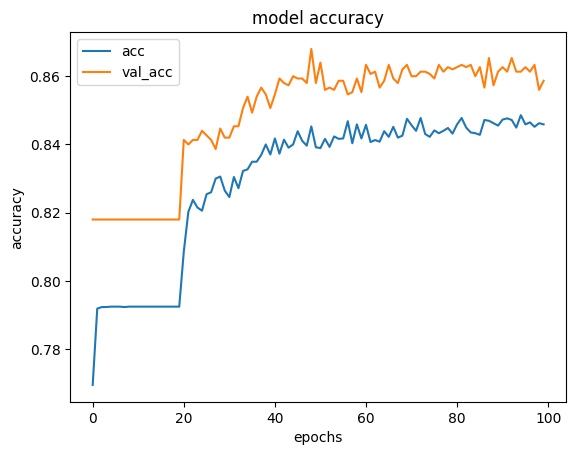

In [63]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["acc", "val_acc"], loc='upper left')
plt.show()

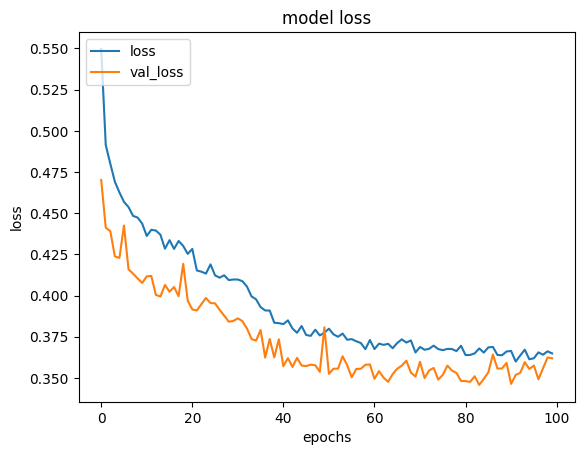

In [64]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(["loss", "val_loss"], loc='upper left')
plt.show()


In [65]:
ypred = model.predict(xtest)
ypred = (ypred>0.5)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [66]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, ypred)
cm

array([[1172,   35],
       [ 155,  138]])

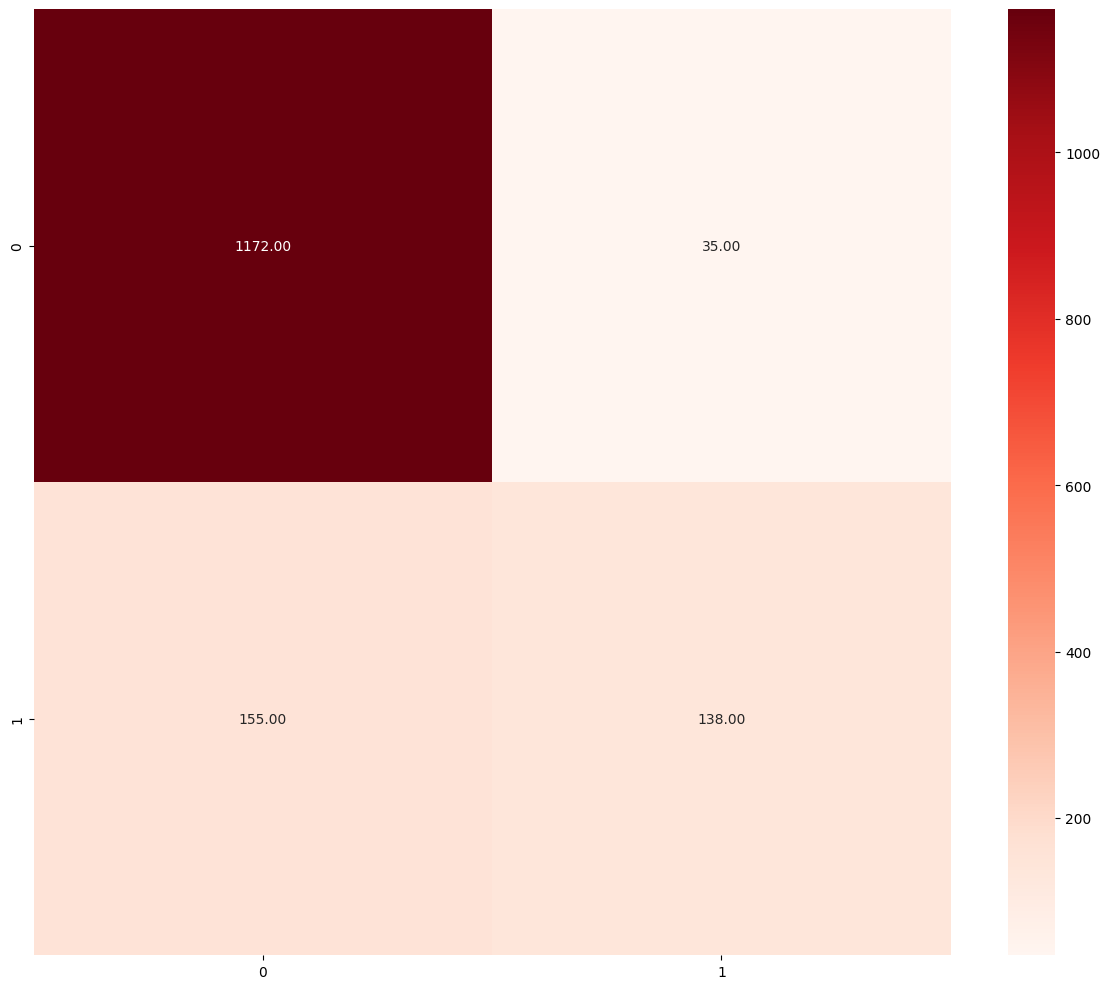

In [67]:
plt.figure(figsize=(12, 10))

sns.heatmap(cm , annot=True, fmt=".2f", cmap='Reds')

plt.tight_layout()
plt.show()

In [68]:
ytest.value_counts()

,count
Exited,
0,1207
1,293


In [69]:
from sklearn.metrics import accuracy_score
score = accuracy_score(ypred,ytest)

In [70]:
from sklearn.metrics import accuracy_score
score = accuracy_score(ypred,ytest)
score

0.8733333333333333

In [71]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,-0.326221,0.0,0.0,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-0.440036,2.0,0.0,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.536794,0.0,0.0,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687
3,0.501521,0.0,0.0,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918
4,2.063884,2.0,0.0,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276


In [72]:
import joblib

# Save weights
joblib.dump(model.get_weights(), "model_weights.pkl")

# Load weights later
weights = joblib.load("model_weights.pkl")
model.set_weights(weights)


In [73]:
joblib.dump(history.history, "history.pkl")

# Load back
history_data = joblib.load("history.pkl")
